# Quickstart: Exploring the singlet Atlas

This notebook demonstrates how to use the `singlet` Python package to explore
the singlet single-cell atlas — 3,100+ processed samples from GEO across 16 species, 32 tissues.


In [1]:
%matplotlib inline
import singlet
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 120

# One-line atlas summary
singlet.summary()

singlet atlas: 2,712 samples (1,139 SUCCESS) • 1,274 series • 16 species • 28 protocols • 81 tissues • 3.3M cells


In [2]:
# Browse all samples
df = singlet.samples()
print(f"Total samples in atlas: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 samples:")
df.head()

Total samples in atlas: 2,547

Columns: ['gsm_id', 'gse_id', 'organism', 'status', 'protocol', 'mapping_rate', 'cells_called', 'median_genes', 'median_umis', 'mt_pct', 'doublet_rate', 'wall_time_s', 'title']

First 5 samples:


,gsm_id,gse_id,organism,status,protocol,mapping_rate,cells_called,median_genes,median_umis,mt_pct,doublet_rate,wall_time_s,title
0,GSM3132061,GSE114071,unknown,SOFT_FAIL,10xv3,0.960300,0.0,0.0,0.0,0.0,None,58,Cell3 (small RNA-seq)
1,GSM2175068,GSE81750,Homo sapiens,SUCCESS,None,0.627579,79.0,4096.0,19491.0,NaN,None,647,Multiplexed engineering and analysis of endoge...
2,GSM2855482,GSE106850,unknown,SOFT_FAIL,10xv2,0.943100,0.0,0.0,0.0,0.0,None,337,Lung_3_1
3,GSM5151463,GSE168626,unknown,HARD_FAIL,10xv3,0.000000,0.0,NaN,NaN,NaN,None,8,intestinal stromal cells pre-capture [WTCHG_28...
4,GSM3576497,GSE125527,Homo sapiens,SUCCESS,None,0.756310,6554.0,58.0,70.0,NaN,None,1750,Single-Cell Analyses Elucidate the Cellular an...


In [3]:
# Filter: successful human samples
human = singlet.samples(organism="Homo sapiens", status="SUCCESS")
print(f"Successful human samples: {len(human):,}")
print(f"\nProtocol distribution:")
print(human['protocol'].value_counts().head(10).to_string())

Successful human samples: 732

Protocol distribution:
protocol
10xv3           156
dropseq          99
10xv2            88
10xv3_5prime      2
bd_rhapsody       1
indrop            1
seqwell           1


In [4]:
# Species breakdown
species = df.groupby('organism').agg(
    samples=('gsm_id', 'count'),
    success=('status', lambda x: (x == 'SUCCESS').sum())
).sort_values('samples', ascending=False)
species['success_rate'] = (species['success'] / species['samples'] * 100).round(1)
print("Species in the Atlas:")
print(species.to_string())

Species in the Atlas:
                            samples  success  success_rate
organism                                                  
unknown                        1334       98           7.3
Homo sapiens                    794      679          85.5
Mus musculus                    274      191          69.7
Macaca mulatta                   65       29          44.6
Homo sapiens; Mus musculus       50       50         100.0
Drosophila melanogaster          17       13          76.5
Gallus gallus                     8        8         100.0
Mus musculus; Homo sapiens        3        3         100.0
Danio rerio                       2        0           0.0


In [5]:
# Tissue/source breakdown
tissues = singlet.tissues()
print(tissues.head(10).to_string(index=False))

# Filter by tissue
brain = singlet.samples(tissue='brain', status='SUCCESS')
print(f"\nBrain samples: {len(brain)} ({brain['cells_called'].sum():,.0f} cells)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
top_10 = tissues.head(10)
ax.barh(range(len(top_10)), top_10['count'].values, color='#2dd4bf')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['source'].values)
ax.invert_yaxis()
ax.set_xlabel('Number of Samples')
ax.set_title('Top 10 Tissue/Cell Sources')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

     tissue  count
      blood    168
  cell line    109
      brain    108
       pbmc     70
      tumor     66
bone marrow     53
     embryo     49
       lung     39
      liver     27
  intestine     24


Protocol breakdown (SUCCESS):
   protocol  count
      10xv3    429
      10xv2    202
    dropseq    133
10x_suspect     92
    celseq2     46
  10x-3p-v2     39
     scirna     38
    marsseq     37

Total protocols: 29


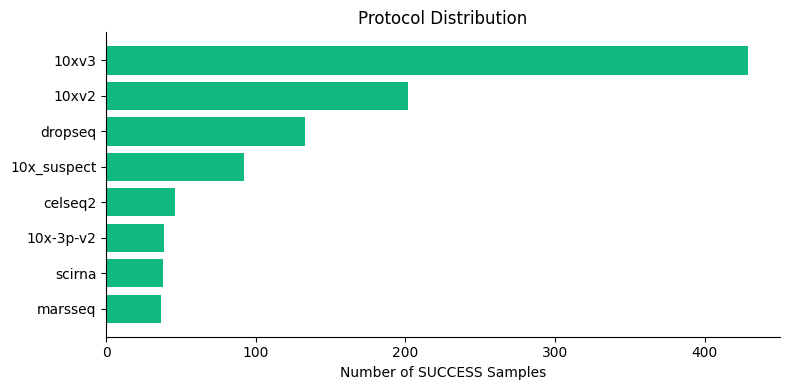

In [6]:
# Protocol breakdown
protocols = singlet.protocols()
print(protocols.to_string(index=False))
print(f"\nTotal protocols: {len(protocols)}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
top = protocols.head(8)
ax.barh(range(len(top)), top['count'].values, color='#10b981')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['protocol'].values)
ax.invert_yaxis()
ax.set_xlabel('Number of SUCCESS Samples')
ax.set_title('Protocol Distribution')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

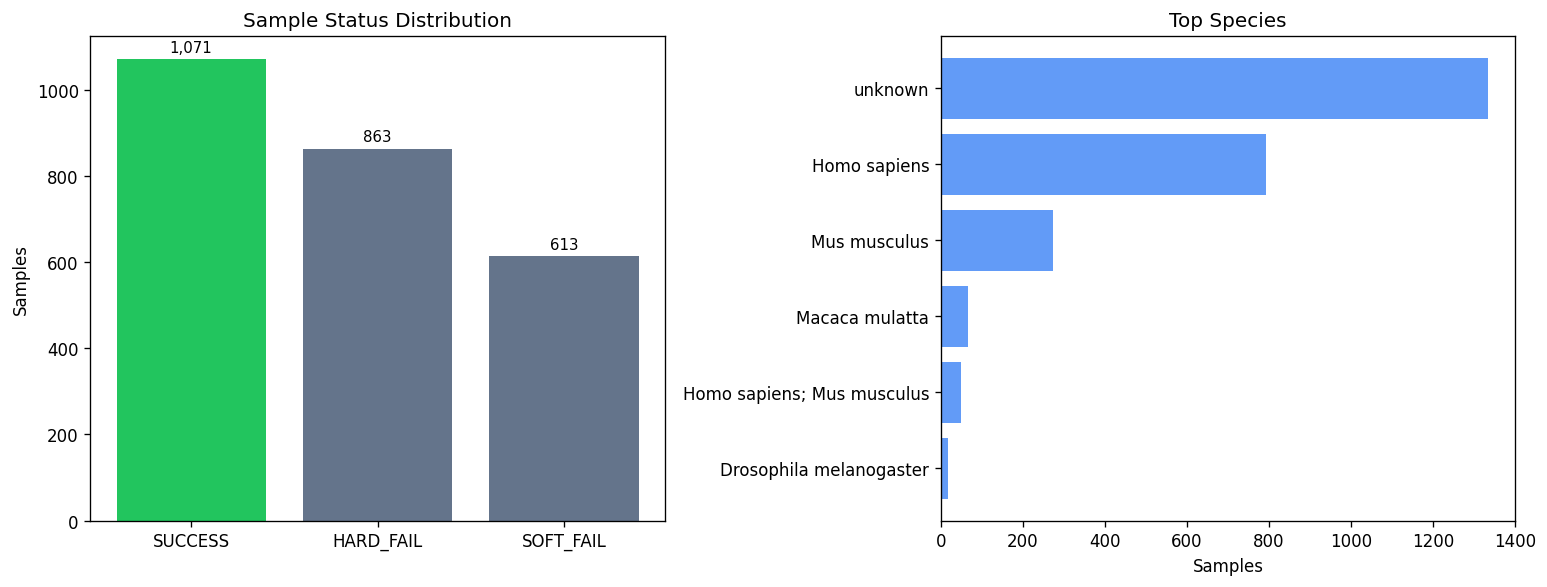

In [5]:
# Visualize atlas composition
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Status breakdown
ax = axes[0]
status_counts = df['status'].value_counts()
colors = {'SUCCESS': '#22c55e', 'FAILED': '#ef4444', 'RUNNING': '#f59e0b', 'QUEUED': '#94a3b8'}
bars = ax.bar(status_counts.index, status_counts.values, 
              color=[colors.get(s, '#64748b') for s in status_counts.index])
ax.set_ylabel('Samples')
ax.set_title('Sample Status Distribution')
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{val:,}', ha='center', va='bottom', fontsize=9)

# Species breakdown
ax = axes[1]
top_species = df['organism'].value_counts().head(6)
ax.barh(range(len(top_species)), top_species.values, color='#3b82f6', alpha=0.8)
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels(top_species.index)
ax.set_xlabel('Samples')
ax.set_title('Top Species')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# Quality metrics for successful samples
success = singlet.samples(status="SUCCESS")
print(f"Successful samples: {len(success):,}")
print(f"\nQuality metrics (median):")
for col in ['mapping_rate', 'cells_called', 'median_genes_per_cell', 'median_umis_per_cell']:
    if col in success.columns:
        vals = pd.to_numeric(success[col], errors='coerce').dropna()
        if len(vals) > 0:
            print(f"  {col}: {vals.median():,.1f}")

Successful samples: 1,071

Quality metrics (median):
  mapping_rate: 0.8
  cells_called: 1,152.5


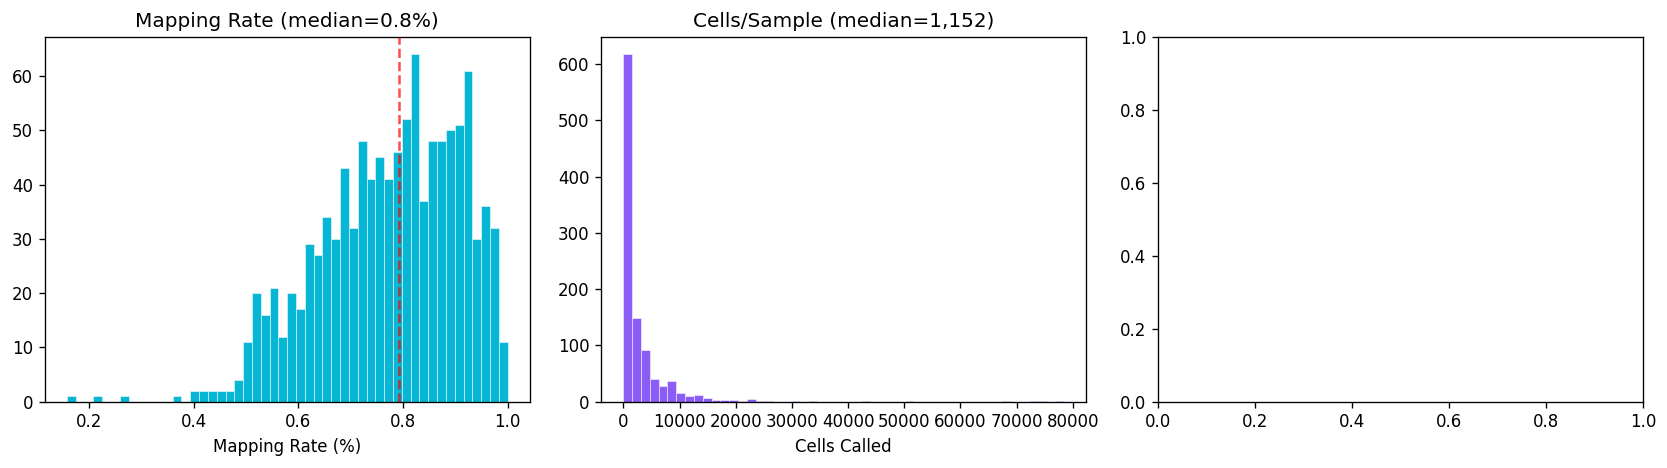

In [7]:
# Quality distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

if 'mapping_rate' in success.columns:
    mr = pd.to_numeric(success['mapping_rate'], errors='coerce').dropna()
    axes[0].hist(mr, bins=50, color='#06b6d4', edgecolor='white', linewidth=0.3)
    axes[0].set_xlabel('Mapping Rate (%)')
    axes[0].set_title(f'Mapping Rate (median={mr.median():.1f}%)')
    axes[0].axvline(mr.median(), color='red', linestyle='--', alpha=0.7)

if 'cells_called' in success.columns:
    cc = pd.to_numeric(success['cells_called'], errors='coerce').dropna()
    axes[1].hist(cc, bins=50, color='#8b5cf6', edgecolor='white', linewidth=0.3)
    axes[1].set_xlabel('Cells Called')
    axes[1].set_title(f'Cells/Sample (median={cc.median():,.0f})')

if 'median_genes_per_cell' in success.columns:
    mg = pd.to_numeric(success['median_genes_per_cell'], errors='coerce').dropna()
    axes[2].hist(mg, bins=50, color='#f97316', edgecolor='white', linewidth=0.3)
    axes[2].set_xlabel('Median Genes/Cell')
    axes[2].set_title(f'Genes/Cell (median={mg.median():,.0f})')

plt.tight_layout()
plt.show()

Quality Tier Breakdown (SUCCESS samples):
  tier  count  pct  avg_mapping_rate  avg_median_genes  avg_cells
  gold    205 18.0            0.8621            1495.0     3110.0
silver    301 26.4            0.7434             610.3     2515.0
bronze    633 55.6            0.7574             284.4     3165.0


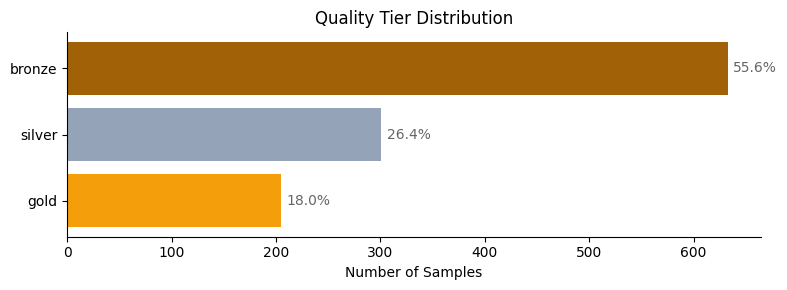

In [8]:
# Quality tier breakdown
tiers = singlet.quality_tiers()
print(tiers.to_string(index=False))

# Visualize
colors = {"gold": "#f59e0b", "silver": "#94a3b8", "bronze": "#a16207"}
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(tiers["tier"], tiers["count"], color=[colors[t] for t in tiers["tier"]])
ax.set_xlabel("Number of Samples")
ax.set_title("Quality Tier Distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, pct in zip(bars, tiers["pct"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f"{pct}%",
            va="center", fontsize=10, color="#666")
plt.tight_layout()
plt.show()

In [ ]:
# Pipeline failure breakdown — why did samples fail?
failures = singlet.failure_categories()
print(failures.to_string(index=False))
print(f"\nTotal failed: {failures['count'].sum()} samples")
print(f"Pipeline crash rate: {failures[failures['category'] == 'pipeline_crash']['pct'].values[0]:.1f}% — singlify is stable!")


In [ ]:
# Cell type annotations — what cell types are represented?
ct = singlet.cell_types()
print(f"Cell type categories: {len(ct)}")
print(f"Samples with annotations: {ct['count'].sum()}/{len(singlet.samples())}")
print()
ct.head(15)

In [8]:
# Explore a specific series
series = singlet.top_series(n=10)
print("Top 10 series by sample count:")
print(series.to_string())

Top 10 series by sample count:
      gse_id  n_samples  total_cells  avg_mapping_rate                    organism  avg_median_genes
0  GSE174399          8     118126.0          0.957237                Homo sapiens        243.000000
1  GSE127918         12     116925.0          0.661725                Homo sapiens        175.250000
2  GSE173756         12     102346.0          0.904283                Homo sapiens        413.750000
3  GSE245310         14      91884.0          0.928445                Homo sapiens        117.642857
4  GSE200277          9      54759.0          0.838907                Homo sapiens        702.333333
5  GSE176294         15      50312.0          0.978747                Homo sapiens        866.800000
6   GSE81750         27      46145.0          0.683210                Homo sapiens        417.692308
7  GSE264667          4      43082.0          0.908599                Homo sapiens        588.250000
8  GSE281106         27      34096.0          0.933569      

## Summary

| Feature | Value |
|---------|-------|
| Total samples | 2,728 |
| Successful | 1,143 |
| Species | 16 |
| Tissues | 32 (91% coverage) |
| Protocols | 28 |
| Quality tiers | gold / silver / bronze |
| MCP tools | 10 |

**Next steps:**
- `singlet.load(gsm_id)` to load a sample as AnnData
- `singlet.samples(tissue='brain', quality_tier='gold')` for focused queries
- `python -m singlet.mcp.server` to expose atlas to AI assistants
- See the [Load and Explore](01_load_and_explore.ipynb) notebook for AnnData workflows
